# **Identifying Argument Structure in John Searle's Texts Using NLI**
---
Authored by: Sangmin Seo


## 1. Introduction
Identifying the structure of an argument within a text is a challenging yet crucial task across various fields, including philosophy. Given that an argument is an expression of inferences, the remarkable benchmark accuracy achieved in machine-based Natural Language Inference (NLI) tasks—thanks to the rapid development of Large Language Models (LLMs)—is noteworthy. However, despite the similarities between natural language argument and NLI, there is a lack of research that links the two fields.

### Research Question and Claims
In this Python notebook, the central question posed is: **Can NLI identify the argument structure in 'Searle (1980)' and 'Searle (2001)' in Wilson et al. (Eds.) (2001)?** I demonstrate that **even a model with a high benchmark score fails to label the argument types in the texts correctly.** Furthermore, even if we assume the existence of a model that labels correctly, **additional techniques and justifications are needed to reliably identify argument structures in the texts.** I will argue the points in Section 4 based on the results of the other sections.

### Data
To support my claims, I will use natural language texts **'Searle (1980)'** and **'Searle (2001)'**, both authored by John Searle. For the dataset, I will also employ the **SNLI corpus** to fine-tune BERT for natural language inference.

The choice of these texts may intrigue some readers, especially given that the Chinese Room argument presented in both works contends that programs do not understand natural language. However, the aim of this study is not to defend or critique the assertions made in these texts. Instead, the works will serve as test cases to evaluate NLI's capability to identify their argumentative structures.

### Techniques
Before diving into the analysis, I will examine the two texts to understand the situational contexts of their arguments. This preparatory work will facilitate a more informed evaluation of **NLI's** capabilities in argument analysis. To prepare the texts for analysis, I will undertake several tasks, including **pre-processing, exploratory analysis, topic modeling, sentence embedding, and text summarization**.

The **fine-tuning** of the model on the SNLI corpus, discussed in Section 3.1, takes approximately 25 minutes when using the T4 GPU and High-RAM configuration on Google Colab. In Section 3.2, I will employ a different model for NLI tasks. (Note: If you're not using the Pro version of Colab, I recommend running the fine-tuning section separately. Running all the code without High-RAM may lead to a crash during the loading of the SNLI corpus. Without a GPU, the fine-tuning process becomes excessively time-consuming.)

In [ ]:
# Settings in the order of sections

# 2.1
!pip install gdown
import gdown
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import string

# 2.2
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# 2.3
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 2.4
!pip install -U sentence-transformers
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# 2.5
!pip install torch
!pip install transformers
from transformers import pipeline
import torch
import textwrap

# 3.1
!pip install d2l==1.0.3
import json
import multiprocessing
import os
from torch import nn
from d2l import torch as d2l
d2l.DATA_HUB['bert.small'] = (d2l.DATA_URL + 'bert.small.torch.zip',
                              'c72329e68a732bef0452e4b96a1c341c8910f81f')
import time

# 3.2
from sentence_transformers import CrossEncoder
from itertools import chain, permutations
import pandas as pd

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 20.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 19.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 34.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.0 MB/s eta 0:00:00
  Created wheel for sentence-transformers: filename=sentence_transformers-2.2.2-py3-none-any.whl size=125923 sha256=c842c31387292739b792887e4624902d2337578eac41bdae0c75582fba8ebb50
  Stored in directory: /root/.cache/pip/wheels/62/f2/10/1e606fd5f02395388f74e7462910fe851042f97238cbbd902f
Successfully built sentence-transformers


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 50.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 102.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 15.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.3/98.3 kB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.8/341.8 kB 32.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.4/93.4 kB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.11.2
    Uninstalling scipy-1.11.2:
      Successfully uninstalled scipy-1.11.2
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 3.1.1
    Uninstalling pyparsing-3.1.1:
     

# 2. Analysing the Target Texts


## 2.1 Pre-processing
I load, clean, and tokenize the texts.

In [ ]:
# Loading the txt of Chinese Room Argument ("cra"), Searle (2001) in Wilson et al. (Eds.). (2001)
cra_url = 'https://drive.google.com/uc?id={}'.format('1-kk1AfKs6v-LzBJmQSKZGsU83SNOFh3c')
gdown.download(cra_url, 'cra.txt', quiet=False)
with open('cra.txt', 'r') as f:
    cra = f.read()
cra
print()

# Replacing line breaks with spaces in cra
cra = cra.replace('\n', ' ')
print(cra)

# Removing punctuation and stopwords
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = ''.join([char for char in text if char not in string.punctuation])
    text = ' '.join([word for word in text.split() if word.lower() not in stop_words])
    return text
clean_cra = clean_text(cra)
print(clean_cra)

# Tokenizing
token_cra = [word for word in clean_cra.split()]
print(token_cra)

Downloading...
From: https://drive.google.com/uc?id=1-kk1AfKs6v-LzBJmQSKZGsU83SNOFh3c
To: /content/cra.txt
100%|██████████| 6.17k/6.17k [00:00<00:00, 17.3MB/s]


Chinese Room Argument The Chinese room argument is a refutation of strong artificial intelligence. “Strong AI” is defined as the view that an appropriately programmed digital computer with the right inputs and outputs, one that satisfies the Turing test, would necessarily have a mind. The idea of Strong AI is that the implemented program by itself is constitutive of having a mind. “Weak AI” is defined as the view that the computer plays the same role in studying cognition as it does in any other discipline. It is a useful device for simulating and therefore studying mental processes, but the programmed computer does not automatically guarantee the presence of mental states in the computer. Weak AI is not criticized by the Chinese room argument. The argument proceeds by the following thought experiment. Imagine a native English speaker, let’s say a man, who knows no Chinese locked in a room full of boxes of Chinese symbols (a data base) together with a book of instructions for manipula

In [ ]:
# Loading the txt of Minds, Brains, and Programs ("mbp") (Searle, 1980).
mbp_url = 'https://drive.google.com/uc?id={}'.format('1-kHLLzWxtSe6suWgjVdKL-eQRf778B2f')
gdown.download(mbp_url, 'mbp.txt', quiet=False)
with open('mbp.txt', 'r') as f:
    mbp = f.read()
mbp
print()

# Replacing needless strings with spaces in mbp
for num in range(236, 253):
    mbp = mbp.replace(str(num), '')
mbp = mbp.replace('John R. Searle', '').replace('JOHN R. SEARLE', '').replace('MINDS, BRAINS, AND PROGRAMS', '')
mbp = mbp.replace('\n', ' ')
print(mbp)

# Removing punctuation and stopwords
clean_mbp = clean_text(mbp)
print(clean_mbp)

# Tokenizing
token_mbp = [word for word in clean_mbp.split()]
print(token_mbp)

Downloading...
From: https://drive.google.com/uc?id=1-kHLLzWxtSe6suWgjVdKL-eQRf778B2f
To: /content/mbp.txt
100%|██████████| 57.0k/57.0k [00:00<00:00, 34.8MB/s]


Minds, brains, and programs  WHAT psychological and philosophical significance should we attach to recent efforts at computer simulations of human cognitive capacities? In answering this question, I find it useful to distinguish what I will call 'strong' AI from 'weak' or 'cautious' AI (Artificial Intelligence). According to weak AI, the principal value of the computer in the study of the mind is that it gives us a very powerful tool. For example, it enables us to formulate and test hypotheses in a more rigorous and precise fashion. But according to strong AI, the computer is not merely a tool in the study of the mind; rather, the appropriately programmed computer really is a mind, in the sense that computers given the right programs can be literally said to understand and have other cognitive states. In strong AI, because the programmed computer has cognitive states, the programs are not mere tools that enable us to test psychological explanations; rather, the programs are themselves

## 2.2 Exploratory Analysis
I count the number of sentences, words, and unique words and display word clouds of the most frequently occurring words.

In [ ]:
# Counting sentences, words, and unique words of cra (using the cra before removing punctuation and stopwords)
cra_sentences = re.split(r'[.!?]', cra)
cra_num_sentences = len([sentence for sentence in cra_sentences if sentence.strip()])

cra_words = cra.split()
cra_num_words = len(cra_words)

cra_num_uniq_words = len(set(cra_words))

cra_num_sentences, cra_num_words, cra_num_uniq_words

(59, 1024, 392)

In [ ]:
# Counting sentences, words, and unique words of mbp (using the mbp before removing punctuation and stopwords)

mbp_sentences = re.split(r'[.!?]', mbp)
mbp_num_sentences = len([sentence for sentence in mbp_sentences if sentence.strip()])

mbp_words = mbp.split()
mbp_num_words = len(mbp_words)

mbp_num_uniq_words = len(set(mbp_words))

mbp_num_sentences, mbp_num_words, mbp_num_uniq_words

(352, 9500, 1984)

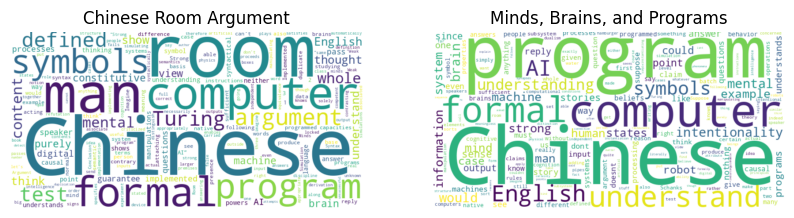

In [ ]:
# Generating wordclouds of cra and mbp

join_token_cra = " ".join(token_cra)
join_token_mbp = " ".join(token_mbp)

cra_word_freq = Counter(join_token_cra.split())
mbp_word_freq = Counter(join_token_mbp.split())

cloud_cra = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(cra_word_freq)
cloud_mbp = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(mbp_word_freq)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cloud_cra, interpolation='bilinear')
plt.axis('off')
plt.title('Chinese Room Argument')
plt.subplot(1, 2, 2)
plt.imshow(cloud_mbp, interpolation='bilinear')
plt.axis('off')
plt.title('Minds, Brains, and Programs')
plt.show()

## 2.3 Topic Modelling
I utilize bag-of-words vectorization and Latent Dirichlet Allocation (LDA) to identify topics, and present them visually using word clouds.

In [ ]:
docs = [clean_cra, clean_mbp]

# Converting text to a bag-of-words
vectorizer = CountVectorizer()
bag = vectorizer.fit_transform(docs)

# Performing LDA
lda = LatentDirichletAllocation(n_components=4, random_state=0)
lda.fit(bag)

# Geting feature names
feature_names = vectorizer.get_feature_names_out()

# Getting topics and their top words
topics = {}
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-9:-1]]
    topics[topic_idx] = top_words

topics
# Topic 0 and 1 are similar, and topic 2 and 3 are similar.

{0: ['shuffling',
  'representation',
  'send',
  'memorizes',
  'mechanism',
  'useful',
  'neurobiological',
  'things'],
 1: ['shuffling',
  'representation',
  'send',
  'memorizes',
  'mechanism',
  'useful',
  'neurobiological',
  'things'],
 2: ['chinese',
  'program',
  'computer',
  'formal',
  'understand',
  'english',
  'ai',
  'symbols'],
 3: ['chinese',
  'room',
  'man',
  'computer',
  'formal',
  'program',
  'turing',
  'argument']}

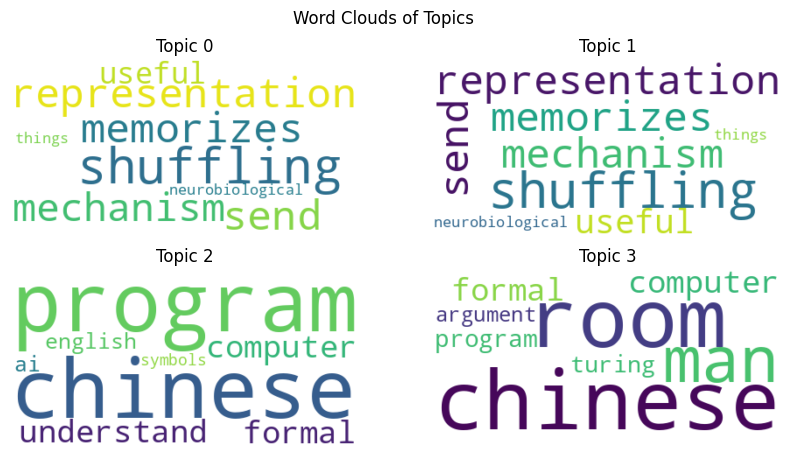

In [ ]:
# Generating word clouds
plt.figure(figsize=(10, 5))
for i, topic in topics.items():
    plt.subplot(2, 2, i+1)
    wordcloud = WordCloud(background_color='white').generate(" ".join(topic))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Topic {i}")
plt.suptitle("Word Clouds of Topics")
plt.show()

## 2.4 Sentence Embedding

Just as word embedding maps individual words to vector representations, sentence embedding does the same for entire sentences. According to Reimers & Gurevych (2019), simply averaging the output layer or using the [CLS] token in BERT does not yield effective sentence embeddings. Instead, they fine-tuned BERT on NLI datasets using specific objective functions. This approach ensures that BERT embeds semantically similar sentences closer together in the vector space. The resulting fine-tuned model is known as Sentence-BERT, and they are further developing Sentence-Transformers that leverage other LLMs. (For more information, visit www.sbert.net.)

In this study, I employ Sentence-Transformer to carry out sentence embedding and visualize the similarities between sentences within each text.

In [ ]:
# Tokenizing and embedding sentences

cra_sentences = sent_tokenize(cra)
mbp_sentences = sent_tokenize(mbp)

# https://www.sbert.net/docs/pretrained_models.html#model-overview
# "The all-mpnet-base-v2 model provides the best quality, while all-MiniLM-L6-v2 is 5 times faster and still offers good quality."
model = SentenceTransformer('all-MiniLM-L6-v2')

cra_embeddings = model.encode(cra_sentences)
mbp_embeddings = model.encode(mbp_sentences)

In [ ]:
# Fit and transform the embeddings to 2D

tsne_model = TSNE(perplexity=30, n_components=2, init='pca', random_state=30)

reduced_cra = tsne_model.fit_transform(cra_embeddings)
reduced_mbp = tsne_model.fit_transform(mbp_embeddings)

x_cra = reduced_cra[:, 0]
y_cra = reduced_cra[:, 1]
x_mbp = reduced_mbp[:, 0]
y_mbp = reduced_mbp[:, 1]

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7e4a58561510>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/threadpoolctl.py", line 847, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.10/dist-packages/threadpoolctl.py", line 984, in _make_controller_from_path
    lib_controller = controller_class(filepath=filepath, prefix=prefix)
  File "/usr/local/lib/python3.10/dist-packages/threadpoolctl.py", line 111, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/usr/lib/python3.10/ctypes/__init__.py", line 374, in __init__
    self._handle = _dlopen(self._name, mode)
OSError: /usr/local/lib/python3.10/dist-packages/scipy.libs/libopenblasp-r0-23e5df77.3.21.dev.so: cannot open shared object file: No such file or directory


In [ ]:
# Plotting embeddings side by side

def plot_embeddings(x1_vals, y1_vals, labels1, x2_vals, y2_vals, labels2):
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Chinese Room Argument", "Minds, Brains, and Programs"))

    trace1 = go.Scatter(x=x1_vals, y=y1_vals, mode='markers', text=labels1)
    trace2 = go.Scatter(x=x2_vals, y=y2_vals, mode='markers', text=labels2)

    fig.add_trace(trace1, row=1, col=1)
    fig.add_trace(trace2, row=1, col=2)

    fig.update_layout(title="Sentence Embeddings")
    fig.show()

plot_embeddings(x_cra, y_cra, cra_sentences, x_mbp, y_mbp, mbp_sentences)

## 2.5 Text Summarization

I employ the LongT5 model, which has been fine-tuned specifically for text summarization tasks. (For more details, see [Hugging Face's LongT5 model](https://huggingface.co/pszemraj/long-t5-tglobal-base-16384-book-summary)). Given that LongT5 is designed to handle long input and output sequences using a text-to-text approach, it is well-suited for the summarization task at hand (Raffel et al., 2019; Guo et al., 2022).

In [ ]:
# Loading the summariser and summarise cra and mbp

summarizer = pipeline(
    "summarization",
    "pszemraj/long-t5-tglobal-base-16384-book-summary",
    device=0 if torch.cuda.is_available() else -1,
)

cra_sum = summarizer(cra)
print(cra_sum[0]["summary_text"])

mbp_sum = summarizer(mbp)
print(mbp_sum[0]["summary_text"])

/usr/local/lib/python3.10/dist-packages/transformers/modeling_utils.py:863: FutureWarning:

The `device` argument is deprecated and will be removed in v5 of Transformers.



Strong artificial intelligence is the view that a properly programmed machine with the correct inputs and outputs would necessarily have an intelligent mind. The argument against strong artificial intelligence goes something like this: An appropriately programmed, digital machine withthe right inputs/outputs, one who satisffies the test, would certainly have a brain. Strong AI means that the program itself is constituative of having 'a mind. WeakAI is the definition of artificial intelligence as the idea that the system does not automatically ensure that there are mental processes in the machine. In other words, weak artificial intelligence doesn't guarantee that there will be a human being in it. This argument starts by thinking about a hypothetical situation where a native speaker knows no Chinese but has to implement a program for manipulating symbols in order to understand Chinese. He can pass the tests for understanding English on the grounds that his program produces the correct 

In [ ]:
# Wrapping summarised texts for convinient reading

cra_sum_str = ' '.join(map(str, cra_sum))
mbp_sum_str = ' '.join(map(str, mbp_sum))

wrap_cra_sum = textwrap.fill(cra_sum_str, width=100)
wrap_mbp_sum = textwrap.fill(mbp_sum_str, width=100)

print(wrap_cra_sum)
print()

print(wrap_mbp_sum)
print()

# The summarised results seem incorrect.

{'summary_text': "Strong artificial intelligence is the view that a properly programmed machine with
the correct inputs and outputs would necessarily have an intelligent mind. The argument against
strong artificial intelligence goes something like this: An appropriately programmed, digital
machine withthe right inputs/outputs, one who satisffies the test, would certainly have a brain.
Strong AI means that the program itself is constituative of having 'a mind. WeakAI is the definition
of artificial intelligence as the idea that the system does not automatically ensure that there are
mental processes in the machine. In other words, weak artificial intelligence doesn't guarantee that
there will be a human being in it. This argument starts by thinking about a hypothetical situation
where a native speaker knows no Chinese but has to implement a program for manipulating symbols in
order to understand Chinese. He can pass the tests for understanding English on the grounds that his
program pro

# 3. Applying Natural Language Inference to Argument Analysis

Natural Language Inference (NLI) is a classification task that takes a premise-hypothesis pair as input and predicts one of three inference types: entailment, contradiction, or neutral. The Stanford NLI corpus (SNLI) and the Multi-NLI corpus (MNLI) are commonly used as training datasets for NLI tasks.




## 3.1 Fine-tuning BERT on SNLI

I fine-tune BERT on the SNLI dataset following the methodology outlined here: [Fine-tuning BERT on SNLI](https://d2l.ai/chapter_natural-language-processing-applications/natural-language-inference-bert.html).

The fine-tuned model achieves an accuracy of approximately 0.8 on the SNLI test dataset. However, I will not use this particular model for subsequent NLI tasks. Instead, I will employ another NLI model in Section 3.2.


In [ ]:
# Defining a function to load the pretrained model
def load_pret_model(model_name, hidden_units, feed_forward_units,
                         attention_heads, blocks, drop_rate, max_sequence_length, target_devices):

    directory_path = d2l.download_extract(model_name)

    # Initializing an empty vocabulary
    vocabulary = d2l.Vocab()

    # Loading the vocabulary
    vocab_file_path = os.path.join(directory_path, 'vocab.json')
    vocabulary.idx_to_token = json.load(open(vocab_file_path))

    # It maps from tokens to indices
    vocabulary.token_to_idx = {token: index for index, token in enumerate(vocabulary.idx_to_token)}

    # Initializing model with given parameters
    bert_model = d2l.BERTModel(
        vocab_size=len(vocabulary),
        num_hiddens=hidden_units,
        ffn_num_hiddens=feed_forward_units,
        num_heads=attention_heads,
        num_blks=blocks,
        dropout=drop_rate,
        max_len=max_sequence_length
    )

    # Loading the pretrained parameters
    params_file_path = os.path.join(directory_path, 'pretrained.params')
    bert_model.load_state_dict(torch.load(params_file_path))

    return bert_model, vocabulary


In [ ]:
# Attempting to get all available GPUs
available_gpus = d2l.try_all_gpus()

# Using CPU if there is no available GPU
if len(available_gpus) == 0:
    print("No GPUs found, using CPU.")
    target_devices = ['cpu']
else:
    print(f"Using GPU: {available_gpus}")
    target_devices = available_gpus

# Loading the pretrained BERT model with vocabulary
bert_model, vocabulary = load_pret_model(
    model_name='bert.small',
    hidden_units=256,
    feed_forward_units=512,
    attention_heads=4,
    blocks=2,
    drop_rate=0.1,
    max_sequence_length=512,
    target_devices=target_devices)

Using GPU: [device(type='cuda', index=0)]


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [ ]:
# Defining a class for the SNLI BERT Dataset
class SNLIBERTData(torch.utils.data.Dataset):

    # Initializing the dataset object
    def __init__(self, input_dataset, max_sequence_length, vocabulary=None):

        # Tokenizing and combining the premise and hypothesis sentences
        tokenized_premise_hypothesis = [
            [premise, hypothesis] for premise, hypothesis in zip(
                *[d2l.tokenize([sentence.lower() for sentence in sent_list])
                  for sent_list in input_dataset[:2]])
        ]

        # Storing the labels as a tensor
        self.labels = torch.tensor(input_dataset[2])

        # Storing the vocabulary
        self.vocab = vocabulary

        # Storing the maximum sequence length
        self.max_sequence_length = max_sequence_length

        # Preprocessing the tokenized premise and hypothesis
        # Getting token IDs, segment IDs, and valid lengths
        (self.all_token_ids, self.all_segment_ids,
         self.valid_lengths) = self._process_tokens(tokenized_premise_hypothesis)

        # Printing the number of preprocessed examples
        print(f'read {len(self.all_token_ids)} examples')

        # Defining the preprocessing
    def _process_tokens(self, combined_premise_hypothesis_tokens):

        # Creating a pool of 4 worker processes for execution
        worker_pool = multiprocessing.Pool(4)

        # Mapping the worker function across all the token pairs in parallel
        processed_results = worker_pool.map(self._worker_for_tokens, combined_premise_hypothesis_tokens)

        # Extracting token IDs from the processed results
        extracted_token_ids = [token_ids for token_ids, seg_ids, valid_length in processed_results]

        # Extracting segment IDs from the processed results
        extracted_segment_ids = [seg_ids for token_ids, seg_ids, valid_length in processed_results]

        # Extracting valid lengths from the processed results
        extracted_valid_lengths = [valid_length for token_ids, seg_ids, valid_length in processed_results]

        # Converting lists to tensors and return
        return (torch.tensor(extracted_token_ids, dtype=torch.long),
                torch.tensor(extracted_segment_ids, dtype=torch.long),
                torch.tensor(extracted_valid_lengths))

        # Defining the multiprocessing worker method for token processing
    def _worker_for_tokens(self, token_pair):
        premise_tokens, hypothesis_tokens = token_pair
        self._trim_token_pair(premise_tokens, hypothesis_tokens)
        combined_tokens, segment_ids = d2l.get_tokens_and_segments(premise_tokens, hypothesis_tokens)

        # Padding or truncating token IDs to reach the maximum sequence length
        padded_token_ids = self.vocab[combined_tokens] + [self.vocab['<pad>']] * (self.max_sequence_length - len(combined_tokens))

        # Padding or truncating segment IDs to reach the maximum sequence length
        padded_segments = segment_ids + [0] * (self.max_sequence_length - len(segment_ids))

        # Calculating the actual length of the token sequence
        actual_length = len(combined_tokens)

        return padded_token_ids, padded_segments, actual_length

    # Defining the method to trim token pairs to a specified maximum length
    def _trim_token_pair(self, premise_tokens, hypothesis_tokens):
        while len(premise_tokens) + len(hypothesis_tokens) > self.max_sequence_length - 3:
            if len(premise_tokens) > len(hypothesis_tokens):
                premise_tokens.pop()
            else:
                hypothesis_tokens.pop()

    # Defining the method to get an item by its index
    def __getitem__(self, index):
        return (self.all_token_ids[index], self.all_segment_ids[index],
                self.valid_lengths[index]), self.labels[index]

    # Defining the method to get the total number of items in the dataset
    def __len__(self):
        return len(self.all_token_ids)


In [ ]:
batch_size_setting, max_sequence_length, worker_count = 256, 128, d2l.get_dataloader_workers()

# Downloading the SNLI corpus
dataset_directory = d2l.download_extract('SNLI')

# Creating training and test sets using the SNLIBERTData
training_dataset = SNLIBERTData(d2l.read_snli(dataset_directory, True), max_sequence_length, vocabulary)
testing_dataset = SNLIBERTData(d2l.read_snli(dataset_directory, False), max_sequence_length, vocabulary)

# Initializing data loaders for training and test sets
training_data_loader = torch.utils.data.DataLoader(training_dataset, batch_size_setting, shuffle=True,
                                                   num_workers=worker_count)
testing_data_loader = torch.utils.data.DataLoader(testing_dataset, batch_size_setting,
                                                  num_workers=worker_count)

read 549367 examples
read 9824 examples


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:560: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [ ]:
# Defining the BERTClassifier class, based on torch's nn.Module
class ClassifierBasedOnBERT(nn.Module):

    # Initializing the classifier
    def __init__(self, preloaded_bert):
        super(ClassifierBasedOnBERT, self).__init__()

        # Using the encoder and hidden layers from the preloaded BERT
        self.text_encoder = preloaded_bert.encoder
        self.hidden_layer = preloaded_bert.hidden

        # Initializing the output layer with 3 units (LazyLinear)
        self.classifier_output = nn.LazyLinear(3)

    def forward(self, input_data):

        token_data, segment_data, valid_length_data = input_data

        # Encoding the input using the BERT encoder
        encoded_representation = self.text_encoder(token_data, segment_data, valid_length_data)

        # Using the hidden layer and getting the output
        return self.classifier_output(self.hidden_layer(encoded_representation[:, 0, :]))


loss 0.430, train acc 0.832, test acc 0.795
2456.2 examples/sec on [device(type='cuda', index=0)]
The training took: 23.98 minutes


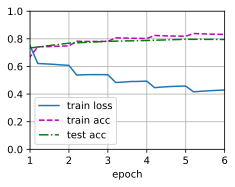

In [ ]:
# Initializing the BERT-based classifier
classifier_model = ClassifierBasedOnBERT(bert_model)

# Setting the learning rate and epochs
learning_rate, total_epochs = 1e-4, 6

# Initializing the optimizer
optimizer = torch.optim.Adam(classifier_model.parameters(), lr=learning_rate)

criterion = nn.CrossEntropyLoss(reduction='none')

classifier_model(next(iter(training_data_loader))[0])

start_time = time.time()

# Training and evaluation
d2l.train_ch13(classifier_model, training_data_loader, testing_data_loader, criterion, optimizer, total_epochs, target_devices)

end_time = time.time()
total_time = end_time - start_time
total_time_minutes = total_time / 60
print(f"The training took: {total_time_minutes:.2f} minutes")

# The result shows accuracy around 0.8 on test sets.
# I will use another model having the higher accuracy for NLI task.

## 3.2 Using an NLI Model for the Chinese Room Argument

To analyze the argument presented by John Searle in his Chinese Room Argument, I will use a fine-tuned DeBERTa model. This model has shown an accuracy of 90.04% on MNLI's topic-mismatched test dataset and was fine-tuned on both the SNLI and MNLI corpora. (For more details, visit [Pre-trained Cross Encoders](https://www.sbert.net/docs/pretrained_cross-encoders.html#nli)).

Additionally, I anticipate that this model will be capable of handling long premises comprising multiple sentences. This expectation is based on the fact that the mean number of words in the premises of the MNLI dataset is 22.3, with the longest premise containing 401 words (Williams et al., 2017). Inputs are tokenized before they are vectorized.

The findings from this section will be discussed and interpreted in Section 4.

In [ ]:
# Definition to print the number of words in premise
def count_word(sentence):
  word_sentence = [word for word in sentence.split()]
  print(f"{len(word_sentence)} is the number of words in the premise '{str(sentence)}'")
  print()

def count_word_total(sentences):
  total_sentences = ' '.join([str(item) for item in sentences])
  count_word(str(total_sentences))

In [ ]:
# This cell is the example provided by a developer of Sentence Transformer.

model = CrossEncoder('cross-encoder/nli-deberta-v3-base')
scores = model.predict([('A man is eating pizza', 'A man eats something'), ('A black race car starts up in front of a crowd of people.', 'A man is driving down a lonely road.')])
print(scores)

# Converting scores to labels
label_mapping = ['contradiction', 'entailment', 'neutral']
labels = [label_mapping[score_max] for score_max in scores.argmax(axis=1)]
print(labels)

/usr/local/lib/python3.10/dist-packages/transformers/convert_slow_tokenizer.py:473: UserWarning:

The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.



[[-5.336721   3.5204756  0.8151884]
 [ 7.7747297 -4.4198465 -2.849666 ]]
['entailment', 'contradiction']


In [ ]:
# Defining the prediction
def predict_nli(text, hypothesis):
    scores_nli = model.predict([(text, hypothesis)])
    labels_nli = [label_mapping[score_max] for score_max in scores_nli.argmax(axis=1)]
    numerical_result = scores_nli.tolist()[0]
    label_result = labels_nli[0]
    return label_result, numerical_result

In [ ]:
# Initializing human prediction to compare it with the model's prediction later.
human_predictions_dict = {}

# Defining function for analysing argument
def perm_argu(premises, conc):
    df = pd.DataFrame(columns=['Premise', 'Conclusion', 'Model Numerical Prediction (contradiction, entailment, neutral)', 'Model Prediction', 'Human Prediction', 'Matched'])

    # Generateing permutations of full premises
    full_premise_perms = list(permutations(premises))
    full_premise_perms_str = [' '.join(perm) for perm in full_premise_perms]


    # Generating permutations of all possible premises.

    premise_perms = chain.from_iterable(permutations(premises, r) for r in range(1, len(premises) + 1))

    for premise_perm in premise_perms:

        # The model prediction of the label for each possible argument.
        # The argument from the full premise to the conclusion is what Searle intends for the arguments in the next cells.
        # However, I also examine other cases to assess the capabilities of NLI.
        combined_premise = ' '.join(premise_perm)
        argument_result, numerical_result = predict_nli(combined_premise, conc)

        # Assigning 'neutral' for human prediction
        human_predictions_dict.setdefault((combined_premise, conc), 'neutral')

        # Changing it into 'entailment' if the premise is full
        if combined_premise in full_premise_perms_str:
            human_predictions_dict[(combined_premise, conc)] = 'entailment'

        human_prediction = human_predictions_dict.get((combined_premise, conc), 'Unknown')

        # Matching model predictions with human predictions
        matched = argument_result == human_prediction

        # Adding to DataFrame
        new_row = pd.DataFrame({
            'Premise': [combined_premise],
            'Conclusion': [conc],
            'Model Numerical Prediction (contradiction, entailment, neutral)': [numerical_result],
            'Model Prediction': [argument_result],
            'Human Prediction': [human_prediction],
            'Matched': [matched]
        })

        # Concatenating to df
        df = pd.concat([df, new_row], ignore_index=True)
        df['Matched'] = df['Matched'].astype(bool)

    return df


### Chinese room argument in mbp

"... As far as the Chinese is concerned, I simply behave like a computer. ...
I have inputs and outputs that are indistinguishable from those of the native Chinese speaker, and I can have any formal program you like, but I still understand nothing. For the same reasons, Schank's computer understands nothing of any stories, whether in Chinese, English, or whatever since in the Chinese case the computer is me, and in cases where the computer is not me, the computer has nothing more than I have in the case where I understand nothing." (Searle, 1980)

In [ ]:
# I summarise Chinese room argument in mbp using Searle's own words.

# Premises
room_mbp = 'As far as the Chinese is concerned, I simply behave like a computer. I have inputs and outputs that are indistinguishable from those of the native Chinese speaker, but I still understand nothing.'
com_mbp = 'In the Chinese case the computer is me, and in cases where the computer is not me, the computer has nothing more than I have in the case where I understand nothing.'
prem_mbp = [room_mbp, com_mbp]

# Conclusion
conc_mbp = 'Computer understands nothing of any stories, whether in Chinese, English, or whatever.'

# The number of words in the full premise
count_word_total(prem_mbp)

# Showing data frame using the argument analysis function
df_mbp = perm_argu(prem_mbp, conc_mbp)
df_mbp

65 is the number of words in the premise 'As far as the Chinese is concerned, I simply behave like a computer. I have inputs and outputs that are indistinguishable from those of the native Chinese speaker, but I still understand nothing. In the Chinese case the computer is me, and in cases where the computer is not me, the computer has nothing more than I have in the case where I understand nothing.'



,Premise,Conclusion,"Model Numerical Prediction (contradiction, entailment, neutral)",Model Prediction,Human Prediction,Matched
0,"As far as the Chinese is concerned, I simply b...","Computer understands nothing of any stories, w...","[-0.5888275504112244, -3.052570104598999, 3.85...",neutral,neutral,True
1,"In the Chinese case the computer is me, and in...","Computer understands nothing of any stories, w...","[4.507930755615234, -3.5429329872131348, -0.28...",contradiction,neutral,False
2,"As far as the Chinese is concerned, I simply b...","Computer understands nothing of any stories, w...","[0.38574469089508057, -2.622856616973877, 2.24...",neutral,entailment,False
3,"In the Chinese case the computer is me, and in...","Computer understands nothing of any stories, w...","[-0.7441945672035217, -2.3887264728546143, 3.1...",neutral,entailment,False


### Chinese room argument in cra
" ... The program enables the person in the room to pass the Turing test for understanding Chinese, but he does not understand a word of Chinese.
The point of the argument is this, if the man in the room does not understand Chinese on the basis of implementing the appropriate program for understanding Chinese, then neither does any other digital computer solely on that basis because no computer, qua computer, has anything the man does not have." (Searle, 2001)

In [ ]:
# Summarising Chinese room argument in mbp using Searle's own words.

# Premises
room_cra = 'The man in the room does not understand Chinese on the basis of implementing the appropriate program for understanding Chinese.'
com_cra = 'No computer, qua computer, has anything the man does not have.'

prem_cra = [room_cra, com_cra]
count_word_total(prem_cra)

# Conclusion
conc_cra = 'Any digital computer does not understand Chinese soley on the basis of implementing the appropriate program for understanding Chinese.'

# Argument analysis data
df_cra = perm_argu(prem_cra, conc_cra)
df_cra

31 is the number of words in the premise 'The man in the room does not understand Chinese on the basis of implementing the appropriate program for understanding Chinese. No computer, qua computer, has anything the man does not have.'



,Premise,Conclusion,"Model Numerical Prediction (contradiction, entailment, neutral)",Model Prediction,Human Prediction,Matched
0,The man in the room does not understand Chines...,Any digital computer does not understand Chine...,"[5.05367374420166, -4.074556350708008, 0.07573...",contradiction,neutral,False
1,"No computer, qua computer, has anything the ma...",Any digital computer does not understand Chine...,"[5.119975566864014, -3.3302736282348633, -1.24...",contradiction,neutral,False
2,The man in the room does not understand Chines...,Any digital computer does not understand Chine...,"[3.061659097671509, -1.7491587400436401, -1.38...",contradiction,entailment,False
3,"No computer, qua computer, has anything the ma...",Any digital computer does not understand Chine...,"[3.0084171295166016, -1.8599125146865845, -1.2...",contradiction,entailment,False


### The larger structure of Chinese room argument
"The larger structure of the argument can be stated as a derivation from three premises.

1. Implemented programs are by definition purely formal or syntactical. ...
2. Minds have mental or semantic contents. ...
3. Syntax is not by itself sufficient for, nor constitutive of, semantics. ...

Conclusion: Implemented programs are not constituitive of minds. Strong AI is false." (Searle, 2001)



In [ ]:
# Premises
prog = 'Implemented programs are by definition purely formal or syntactical.'
mind = 'Minds have mental or semantic contents.'
suf = 'Syntax is not by itself sufficient for, nor constitutive of, semantics.'

prem_larg = [prog, mind, suf]
count_word_total(prem_larg)

# Conclusion
conc_larg = 'Implemented programs are not constitutive of minds.'

# Argument analysis data
df_larg = perm_argu(prem_larg, conc_larg)
df_larg

26 is the number of words in the premise 'Implemented programs are by definition purely formal or syntactical. Minds have mental or semantic contents. Syntax is not by itself sufficient for, nor constitutive of, semantics.'



,Premise,Conclusion,"Model Numerical Prediction (contradiction, entailment, neutral)",Model Prediction,Human Prediction,Matched
0,Implemented programs are by definition purely ...,Implemented programs are not constitutive of m...,"[1.7659857273101807, -3.4161300659179688, 2.40...",neutral,neutral,True
1,Minds have mental or semantic contents.,Implemented programs are not constitutive of m...,"[0.4966862201690674, -2.494821071624756, 2.352...",neutral,neutral,True
2,"Syntax is not by itself sufficient for, nor co...",Implemented programs are not constitutive of m...,"[-2.1066083908081055, -1.6967061758041382, 3.6...",neutral,neutral,True
3,Implemented programs are by definition purely ...,Implemented programs are not constitutive of m...,"[2.8950250148773193, -1.5937528610229492, -1.2...",contradiction,neutral,False
4,Implemented programs are by definition purely ...,Implemented programs are not constitutive of m...,"[-2.931492805480957, -1.1872965097427368, 3.72...",neutral,neutral,True
5,Minds have mental or semantic contents. Implem...,Implemented programs are not constitutive of m...,"[1.1287004947662354, -0.3859659731388092, -0.7...",contradiction,neutral,False
6,Minds have mental or semantic contents. Syntax...,Implemented programs are not constitutive of m...,"[-3.9795520305633545, -1.057598352432251, 4.66...",neutral,neutral,True
7,"Syntax is not by itself sufficient for, nor co...",Implemented programs are not constitutive of m...,"[-1.5074206590652466, -2.285134792327881, 3.71...",neutral,neutral,True
8,"Syntax is not by itself sufficient for, nor co...",Implemented programs are not constitutive of m...,"[-4.394920825958252, -0.6434035897254944, 4.63...",neutral,neutral,True
9,Implemented programs are by definition purely ...,Implemented programs are not constitutive of m...,"[-2.5563385486602783, 2.6952452659606934, -0.8...",entailment,entailment,True


<a name="my_section"></a>

In [ ]:
# I paraphrase the original statements, and analyse all the possible arguments like before.

# Premises
prog_para = 'If a computer program has been executed, the program is necessarily a set of formal rules or syntax.'
mind_para = 'Human cognitive processes contain elements that are mental or semantic.'
suf_para = 'Syntax in isolation is not enough to form semantics.'

prem_para = [prog_para, mind_para, suf_para]

count_word_total(prem_para)

# Conclusion
conc_para = 'Executed computer programs do not make up minds.'

# Analysis data
df_para = perm_argu(prem_para, conc_para)
df_para

37 is the number of words in the premise 'If a computer program has been executed, the program is necessarily a set of formal rules or syntax. Human cognitive processes contain elements that are mental or semantic. Syntax in isolation is not enough to form semantics.'



,Premise,Conclusion,"Model Numerical Prediction (contradiction, entailment, neutral)",Model Prediction,Human Prediction,Matched
0,"If a computer program has been executed, the p...",Executed computer programs do not make up minds.,"[5.048762798309326, -3.1825647354125977, -1.41...",contradiction,neutral,False
1,Human cognitive processes contain elements tha...,Executed computer programs do not make up minds.,"[6.133025646209717, -3.5719056129455566, -2.12...",contradiction,neutral,False
2,Syntax in isolation is not enough to form sema...,Executed computer programs do not make up minds.,"[-2.5302371978759766, -1.7852131128311157, 4.1...",neutral,neutral,True
3,"If a computer program has been executed, the p...",Executed computer programs do not make up minds.,"[4.190296649932861, -2.6203725337982178, -1.30...",contradiction,neutral,False
4,"If a computer program has been executed, the p...",Executed computer programs do not make up minds.,"[-1.2057907581329346, -1.21138334274292, 2.220...",neutral,neutral,True
5,Human cognitive processes contain elements tha...,Executed computer programs do not make up minds.,"[4.74323034286499, -3.0978240966796875, -1.197...",contradiction,neutral,False
6,Human cognitive processes contain elements tha...,Executed computer programs do not make up minds.,"[-4.70784330368042, 1.419660210609436, 2.50249...",neutral,neutral,True
7,Syntax in isolation is not enough to form sema...,Executed computer programs do not make up minds.,"[3.870173931121826, -2.542768955230713, -0.974...",contradiction,neutral,False
8,Syntax in isolation is not enough to form sema...,Executed computer programs do not make up minds.,"[-4.596533298492432, 3.378560781478882, 0.1127...",entailment,neutral,False
9,"If a computer program has been executed, the p...",Executed computer programs do not make up minds.,"[-0.060227055102586746, -0.6557021141052246, 0...",neutral,entailment,False


In [ ]:
# Adding identifier
df_cra['Argument Class'] = 'CRA'
df_mbp['Argument Class'] = 'MBP'
df_larg['Argument Class'] = 'LARG'
df_para['Argument Class'] = 'LARG_PARA'

# Combining data
fin_df = pd.concat([df_cra, df_mbp, df_larg, df_para], ignore_index=True)
fin_df

,Premise,Conclusion,"Model Numerical Prediction (contradiction, entailment, neutral)",Model Prediction,Human Prediction,Matched,Argument Class
0,The man in the room does not understand Chines...,Any digital computer does not understand Chine...,"[5.05367374420166, -4.074556350708008, 0.07573...",contradiction,neutral,False,CRA
1,"No computer, qua computer, has anything the ma...",Any digital computer does not understand Chine...,"[5.119975566864014, -3.3302736282348633, -1.24...",contradiction,neutral,False,CRA
2,The man in the room does not understand Chines...,Any digital computer does not understand Chine...,"[3.061659097671509, -1.7491587400436401, -1.38...",contradiction,entailment,False,CRA
3,"No computer, qua computer, has anything the ma...",Any digital computer does not understand Chine...,"[3.0084171295166016, -1.8599125146865845, -1.2...",contradiction,entailment,False,CRA
4,"As far as the Chinese is concerned, I simply b...","Computer understands nothing of any stories, w...","[-0.5888275504112244, -3.052570104598999, 3.85...",neutral,neutral,True,MBP
5,"In the Chinese case the computer is me, and in...","Computer understands nothing of any stories, w...","[4.507930755615234, -3.5429329872131348, -0.28...",contradiction,neutral,False,MBP
6,"As far as the Chinese is concerned, I simply b...","Computer understands nothing of any stories, w...","[0.38574469089508057, -2.622856616973877, 2.24...",neutral,entailment,False,MBP
7,"In the Chinese case the computer is me, and in...","Computer understands nothing of any stories, w...","[-0.7441945672035217, -2.3887264728546143, 3.1...",neutral,entailment,False,MBP
8,Implemented programs are by definition purely ...,Implemented programs are not constitutive of m...,"[1.7659857273101807, -3.4161300659179688, 2.40...",neutral,neutral,True,LARG
9,Minds have mental or semantic contents.,Implemented programs are not constitutive of m...,"[0.4966862201690674, -2.494821071624756, 2.352...",neutral,neutral,True,LARG


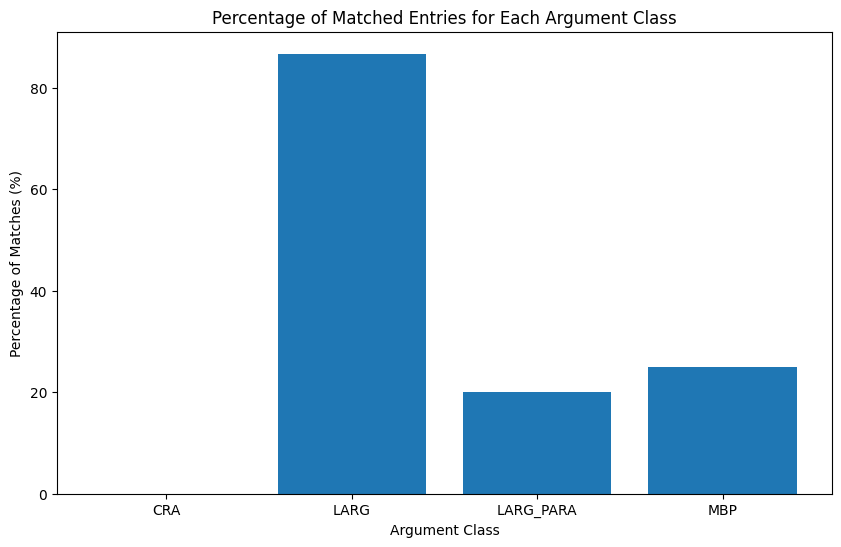

In [ ]:
# Grouping by 'Argument Class' and summing the number of matched
grouped_sum = fin_df.groupby('Argument Class')['Matched'].sum()

# Counting the total number of entries for each 'Argument Class'
grouped_count = fin_df.groupby('Argument Class')['Matched'].count()

# Calculating the percentage of matched entries
grouped_percentage = (grouped_sum / grouped_count) * 100

# Plotting
def match_argu():
  plt.figure(figsize=(10, 6))
  plt.bar(grouped_percentage.index, grouped_percentage.values)
  plt.xlabel('Argument Class')
  plt.ylabel('Percentage of Matches (%)')
  plt.title('Percentage of Matched Entries for Each Argument Class')
  return plt.show()

match_argu()

# 4. Limits of Identifying the Argument Structure of the Chinese Room Argument Using NLI



## 4.1 Limits of Labeling Argument Types

I will argue that, based on the results, the correct analysis of argument types is restricted to very clear arguments, such as LARG, at least when using the model I employed.

For arguments that have a complete premise, I assigned the label "entailment," and for all others, I assigned "neutral." These assignments align with human predictions for specific reasons. According to Korman et al. (2018), textual entailment is defined as follows: $T$ textually entails $H$ if "typically, a human reading $T$ would be justified in inferring the proposition expressed by $H$ from the proposition expressed by $T$." This definition avoids many counterexamples proposed by Korman et al.

Recognizing Textual Entailment (RTE) is a task similar to NLI. We can state that 'contradiction' occurs when $T$ textually entails $\neg H$, and 'neutral' occurs when $T$ neither textually entails $H$ nor $\neg H$.

Furthermore, this definition aligns with the labeling instructions for SNLI and MNLI. Annotators for these datasets were instructed to label the hypothesis as definitely true or correct (entailment), possibly true or correct (neutral), or definitely false or incorrect (contradiction), based on the premise (Bowman, 2015; Williams, 2017).

It is sufficient to judge NLI labels based on the definition of textual entailment. If a human reader would typically be justified in inferring $ H$ from $T$, then people will judge that $H$ is true based on $T$. Conversely, if $\neg H$ would typically be inferred from $T$, then $H$ would be judged as false or incorrect based on $T$. If neither $H$ nor $\neg H$ is typically inferred from $T$, then $H$ will be judged as possibly true or possibly false based on $T$. Therefore, we can apply the definition of textual entailment when making human predictions about analyzing argument structures.

Let's reconsider the summarized Chinese Room argument based on Searle's work from 1980.

Premise 1: As far as the Chinese is concerned, I simply behave like a computer. I have inputs and outputs that are indistinguishable from those of the native Chinese speaker, but I still understand nothing. (room_mbp)

Premise 2: In the Chinese case the computer is me, and in cases where the computer is not me, the computer has nothing more than I have in the case where I understand nothing. (com_mbp)

Conclusion: Computer understands nothing of any stories, whether in Chinese, English, or whatever. (conc_mbp)

If a computer does not understand Chinese, just as I don't in the Chinese Room, then it follows that the computer does not understand stories written in Chinese. Furthermore, if the computer lacks understanding, similar to how I lack understanding for other languages, then it can be concluded that computers do not understand stories written in any language. People would typically be justified in inferring 'conc_mbp' from 'room_mbp' and 'com_mbp'. While the arguments themselves may be false or debatable, their structural logic holds if we assume the premises to be true. This would categorize them as "entailments" in the context of NLI.

However, if one of the premises is missing, the conclusion 'conc_mbp' is not justified. For instance, if 'room_mbp' is not assumed, it is possible that I understand some languages, including Chinese. Therefore, the computer might also understand Chinese. This is because, although the computer is likened to me, there is no assumption that I am in the room processing Chinese without any understanding. In this case, neither 'conc_mbp' nor $\neg$'conc_mbp' is justified, as it is also plausible that the computer understands nothing. Therefore, the argument is neither an entailment nor a contradiction; it is neutral.

Similarly, if 'com_mbp' is not assumed, it's possible that the computer might understand some stories, as it could be more capable than I am in the room. Thus, 'conc_mbp' could still be true or false, making the argument neutral in this case as well. Other types of arguments, such as CRA, LARG, and LARG_PARA, can be analyzed in a similar manner.

LARG appears to have a more straightforward structure:

Premise 1: Implemented programs are by definition purely formal or syntactical. (prog)

Premise 2: Minds have mental or semantic contents. (mind)

Premise 3: Syntax is not by itself sufficient for, nor constitutive of, semantics. (suf)

Conclusion: Implemented programs are not constitutive of minds. (conc_larg)

Let $P$ represent '$x$ is an implemented program,' $Y$ represent '$x$ is by definition purely formal or syntactical,' $M$ represent '$x$ is a mind,' and $S$ represent '$x$ has mental or semantic contents.' Then, 'prog' is $P \rightarrow Y$, 'mind' is $M \rightarrow S$, 'suf' is $Y \rightarrow \neg S$, and 'conc_larg' is $P \rightarrow \neg M$. By the contrapositive of 'suf,' $S \rightarrow \neg Y$ holds. Similarly, by the contrapositive of 'prog,' $\neg Y \rightarrow \neg P$ holds. Thus, $S \rightarrow \neg P$, and by 'mind,' $M \rightarrow \neg P$. Therefore, $P \rightarrow \neg M$. Typically, a human would be justified in inferring 'conc_larg' from the conjunction of these premises, making the conclusion an entailment. If any premise is omitted, the conclusion is neither entailed nor contradicted. Paraphrased versions also maintain the same structure.

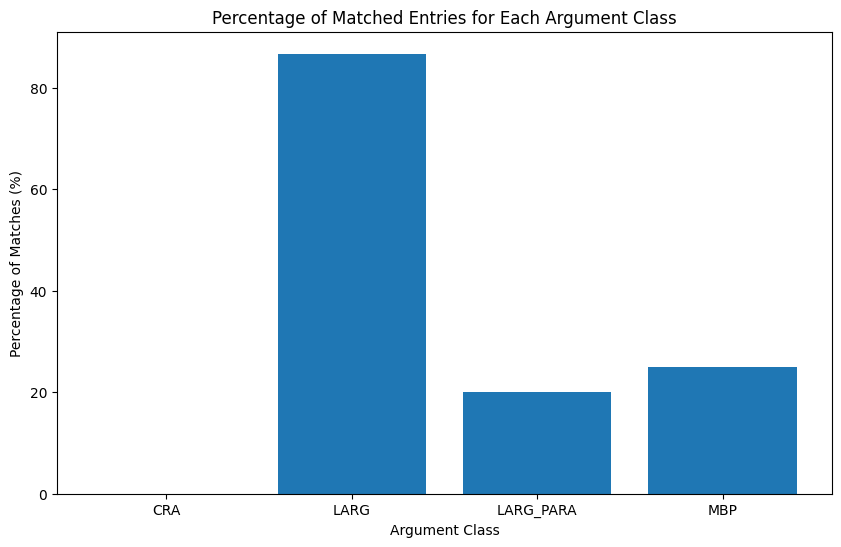

In [ ]:
match_argu()

As the plot shows, most predictions for labels do not align with human predictions, except for LARG. Furthermore, the human predictions for each conjunction of all premises to each conclusion do not match at all with the model predictions, while LARG's predictions are all consistent.

In [ ]:
entail_df = fin_df[fin_df['Human Prediction'] == 'entailment']
entail_df

,Premise,Conclusion,"Model Numerical Prediction (contradiction, entailment, neutral)",Model Prediction,Human Prediction,Matched,Argument Class
2,The man in the room does not understand Chines...,Any digital computer does not understand Chine...,"[3.061659097671509, -1.7491587400436401, -1.38...",contradiction,entailment,False,CRA
3,"No computer, qua computer, has anything the ma...",Any digital computer does not understand Chine...,"[3.0084171295166016, -1.8599125146865845, -1.2...",contradiction,entailment,False,CRA
6,"As far as the Chinese is concerned, I simply b...","Computer understands nothing of any stories, w...","[0.38574469089508057, -2.622856616973877, 2.24...",neutral,entailment,False,MBP
7,"In the Chinese case the computer is me, and in...","Computer understands nothing of any stories, w...","[-0.7441945672035217, -2.3887264728546143, 3.1...",neutral,entailment,False,MBP
17,Implemented programs are by definition purely ...,Implemented programs are not constitutive of m...,"[-2.5563385486602783, 2.6952452659606934, -0.8...",entailment,entailment,True,LARG
18,Implemented programs are by definition purely ...,Implemented programs are not constitutive of m...,"[-4.1950883865356445, 3.5767664909362793, -0.5...",entailment,entailment,True,LARG
19,Minds have mental or semantic contents. Implem...,Implemented programs are not constitutive of m...,"[-3.499418258666992, 3.299201726913452, -0.855...",entailment,entailment,True,LARG
20,Minds have mental or semantic contents. Syntax...,Implemented programs are not constitutive of m...,"[-2.2679576873779297, 2.296130895614624, -0.56...",entailment,entailment,True,LARG
21,"Syntax is not by itself sufficient for, nor co...",Implemented programs are not constitutive of m...,"[-2.6147689819335938, 2.517941951751709, -0.59...",entailment,entailment,True,LARG
22,"Syntax is not by itself sufficient for, nor co...",Implemented programs are not constitutive of m...,"[-2.992833137512207, 2.9686546325683594, -0.83...",entailment,entailment,True,LARG


This discrepancy may be because LARG has a clearer structure and content than other arguments like LARG_PARA. Specifically, the term 'mind' is used instead of 'cognitive processes,' which lends greater clarity to the argument.

- 'mind': Minds have mental or semantic contents.
- 'mind_para': Human cognitive processes contain elements that are mental or semantic.

However, natural language arguments are generally less clear-cut than LARG. Therefore, we can conclude that NLI models, particularly the DeBERTa model which achieves approximately 90% accuracy on the NLI test dataset, are not effective at analyzing argument types found in 'cra' and 'mbp'.

In subsequent sections, I will argue that identifying the argument structure of 'cra' or 'mbp' requires the integration of additional complementary techniques, even if we assume the existence of a model that labels argument types correctly.

## 4.2 The Need for Argument Mining

Before analyzing the labels of arguments, it's essential to first identify the arguments and their components within texts like 'cra' or 'mbp'. For my argument analysis, I manually extracted the arguments and their individual components, such as premises and conclusions, as well as the relationships between these components (e.g., whether the conjunction of all premises entails the conclusion). This process is necessary even for clearly structured arguments like LARG, especially when embedded in a larger text like 'cra,' which contains 1024 words.

In [ ]:
print(cra_num_words)
print(mbp_num_words)

1024
9500


Even if premises and conclusions seem clearly ordered and labeled to a human reader, they still need to be explicitly identified. Furthermore, it's also important to determine whether the combined premises entail the conclusion, particularly if multiple arguments are presented.



Some might suggest analyzing the entire text with Natural Language Inference (NLI). However, relying solely on NLI for natural language text is computationally inefficient. Let $n$ be the number of sentences in a natural language text. If NLI is correct, the inference from a premise to a conjunction of premises can be derived from the inferences from the premise to each sentence in the conjunction. Thus, when the premise consists of one sentence, the number of cases is $\binom{n}{1} \cdot \binom{n-1}{1}$. For a premise with two sentences, the number of cases is $\binom{n}{2} \cdot \binom{n-2}{1}$. (Note that inference from the conjunction of $n$ sentences to the conclusion is not derived from the inference from a single-sentence premise to the conclusion.) For a premise with $n-1$ sentences, the number of cases is $\binom{n}{n-1} \cdot \binom{1}{1}$. Therefore, NLI needs to be performed $\binom{n}{1}\cdot \binom{n-1}{1} + \binom{n}{2}\cdot \binom{n-2}{1} + \ldots + \binom{n}{n-1}\cdot \binom{1}{1} = \sum_{k=1}^{n-1} \binom{n}{k} \cdot \binom{n-k}{1}$ times.

This number grows significantly larger than \( 2^n \) as \( n \) increases, as illustrated in the graph below.

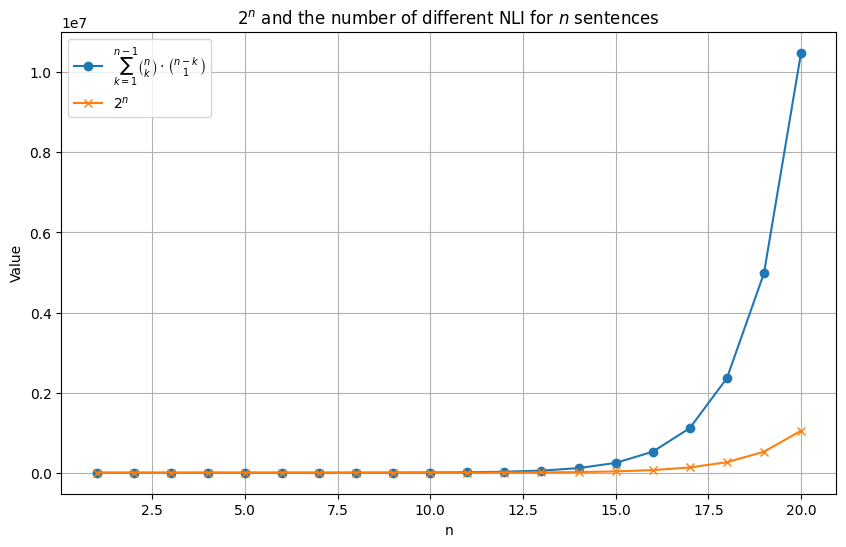

In [ ]:
import numpy as np
from scipy.special import comb

# Defining the function for the number of different NLI for n sentences
def nli_exe(n):
    total = 0
    for k in range(1, n):
        total += comb(n, k) * comb(n - k, 1)
    return total

# Defining the function for 2^n
def two_power(n):
    return 2 ** n

n_values = np.arange(1, 21)

# Calculating the y-values
nli_exe_values = [nli_exe(n) for n in n_values]
two_power_values = [two_power(n) for n in n_values]

# Graph
plt.figure(figsize=(10, 6))
plt.plot(n_values, nli_exe_values, label=r"$\sum_{k=1}^{n-1} \binom{n}{k} \cdot \binom{n-k}{1}$", marker='o')
plt.plot(n_values, two_power_values, label=r"$2^n$", marker='x')
plt.xlabel("n")
plt.ylabel("Value")
plt.title("$2^n$ and the number of different NLI for $n$ sentences")
plt.legend()
plt.grid(True)
plt.show()


Considering the number of sentences in 'cra' and 'mbp,' which are 59 and 352 respectively, the numbers \(2^{59}\) and \(2^{352}\) are already computationally inefficient.



In [ ]:
print(cra_num_sentences)
print(mbp_num_sentences)

59
352


What about reducing the number of sentences using text summarization techniques?

In [ ]:
print('Summary of cra')
print(wrap_cra_sum)
print()
print('Summary of mbp')
print(wrap_mbp_sum)

Summary of cra
{'summary_text': "Strong artificial intelligence is the view that a properly programmed machine with
the correct inputs and outputs would necessarily have an intelligent mind. The argument against
strong artificial intelligence goes something like this: An appropriately programmed, digital
machine withthe right inputs/outputs, one who satisffies the test, would certainly have a brain.
Strong AI means that the program itself is constituative of having 'a mind. WeakAI is the definition
of artificial intelligence as the idea that the system does not automatically ensure that there are
mental processes in the machine. In other words, weak artificial intelligence doesn't guarantee that
there will be a human being in it. This argument starts by thinking about a hypothetical situation
where a native speaker knows no Chinese but has to implement a program for manipulating symbols in
order to understand Chinese. He can pass the tests for understanding English on the grounds that 

However, the results in Section 2.5 appear to be incorrect. For example, the summary of 'cra' states, "The argument against strong artificial intelligence goes something like this: An appropriately programmed, digital machine withthe right inputs/outputs, one who satisffies the test, would certainly have a brain." This assertion contradicts the original 'cra' argument, which does not claim that such machines would have brains. Additionally, none of the summaries for 'mbp' or 'cra' contain any sentences that resemble the main conclusions of the arguments—namely, 'conc_mbp,' 'conc_cra,' or 'conc_larg.'



In [ ]:
print(conc_cra)
print(conc_larg)
print(conc_mbp)

Any digital computer does not understand Chinese soley on the basis of implementing the appropriate program for understanding Chinese.
Implemented programs are not constitutive of minds.
Computer understands nothing of any stories, whether in Chinese, English, or whatever.


Even if we assume the existence of a model capable of accurate summarization, it may still omit some arguments. Therefore, it seems more appropriate to focus on improving and employing argument mining techniques for our purposes. The process of argument mining aligns well with our objective of identifying argument structures in 'mbp' and 'cra.' According to Lawrence & Reed (2020) and Ruiz-dolz et al. (2021), the task of argument mining consists of three sub-tasks:

1. Distinguishing arguments from non-arguments.
2. Identifying clausal properties, such as premises and conclusions.
3. Determining the relationships between argumentative propositions.

## 4.3 The Need for Probabilistic Analysis

What is another challenge in identifying argument structures from natural language texts like 'cra' and 'mbp' arises even when we have a model that labels argument types accurately? In many instances, argument analysis requires a probabilistic interpretation. For example, consider the following case from Chen et al. (2020):

- (Premise) A boy hits a ball with a bat.
- (Hypothesis) The boy is playing in a baseball game.

While this example is labeled as an "entailment" in the Stanford Natural Language Inference (SNLI) dataset, it could arguably be considered "neutral."

In [ ]:
P1 = 'A boy hits a ball with a bat.'
H1 = 'The boy is playing in a baseball game.'
print(predict_nli(P1, H1))

('neutral', [-3.7382233142852783, -1.6424901485443115, 5.113292694091797])


 A more specific label might be to assign a probability of around 0.9 to its being an entailment.

In the arguments we are examining, omitting a premise often leads to a "neutral" label.

In [ ]:
room_mbp = 'As far as the Chinese is concerned, I simply behave like a computer. I have inputs and outputs that are indistinguishable from those of the native Chinese speaker, but I still understand nothing.'
conc_mbp = 'Computer understands nothing of any stories, whether in Chinese, English, or whatever.'
print(predict_nli(room_mbp, conc_mbp))

('neutral', [-0.5888275504112244, -3.052570104598999, 3.8556387424468994])


In [ ]:
prog = 'Implemented programs are by definition purely formal or syntactical.'
suf = 'Syntax is not by itself sufficient for, nor constitutive of, semantics.'
conc_larg = 'Implemented programs are not constitutive of minds.'
print(predict_nli(prog + ' ' + suf, conc_larg))

('neutral', [-2.931492805480957, -1.1872965097427368, 3.7291834354400635])


(The model's prediction is also 'neutral' in this case.) However, labeling probabilities would be more specific because the conclusion will have a probability between 0 and 1, depending on the actual probability of the excluded premise. For example, if the probability of 'com_mbp' is actually high, the argument from 'room_mbp' to 'conc_mbp' would also have a high probability.

As can be seen, a more nuanced approach would be to evaluate it in terms of subjective probability. This is the idea behind "Uncertain NLI" (UNLI), as proposed by Chen et al. (2020). They created a dataset called u-SNLI by relabeling approximately 12% of the pairs in the original SNLI dataset. By fine-tuning BERT on both SNLI and u-SNLI, they achieved performance metrics close to human levels on development and test datasets. For instance, the transition from 'A man is singing into a microphone' to 'A man is performing on stage' is labeled as 84% in u-SNLI (and as 'neutral' in SNLI).

However, this does not mean that the model has human-level accuracy for all possible premise-hypothesis pairs. Additional UNLI data and experiments are needed to more fully evaluate probabilistic reasoning and inference.

## 4.4 The Need for Justification

Certain cases in Natural Language Inference (NLI) may require additional justification. Some inferences are straightforward for humans to grasp. For example, the statement 'Quine is married' contradicts the hypothesis 'Quine is a bachelor.'

In [ ]:
P2 = 'Quine is married.'
H2 = 'Quine is a bachelor.'
print(predict_nli(P2, H2))

('contradiction', [6.863809108734131, -3.6253762245178223, -3.02125883102417])


However, there are instances where the model computes inferences as entailments or contradictions, and it's challenging to understand the reasoning behind such labels. For the argument type LARG, the model accurately predicted all labels except for two. While this could be attributed to a limitation of the model, it's not clear whether the human prediction (neutral) or the model's prediction (contradiction) is correct, especially if we generally assume the model to be accurate.





In [ ]:
mind = 'Minds have mental or semantic contents.'
prog = 'Implemented programs are by definition purely formal or syntactical.'
conc_larg = 'Implemented programs are not constitutive of minds.'
print(predict_nli(mind + ' ' + prog, conc_larg))
print(predict_nli(prog + ' ' + mind, conc_larg))

('contradiction', [1.1287004947662354, -0.3859659731388092, -0.7378013134002686])
('contradiction', [2.8950250148773193, -1.5937528610229492, -1.2488163709640503])


These kinds of inferences are akin to human intuitive reasoning, where explicit justification may not be readily available. NLI models don't operate with formal proofs or structured arguments. If we could establish the validity of an NLI model's learning and prediction processes, it would lend more credence to the inferences made by the model.

However, the architecture of Artificial Neural Networks (ANNs) used in these models, along with their "black box" nature, complicates any straightforward analysis. This raises further questions about the interpretability and explainability of such models.

The generation of additional arguments might provide the needed justification for certain inferences. For instance, consider an argument of the form "$p$, therefore $q$" that is labeled as 0.1, indicating a contradiction. If the rationale behind this label is unclear, introducing an intermediate premise $p'$ could shed light on the situation. If a model finds $p'$ such that the argument "$p$, therefore $p'$" is labeled as 1 (indicating entailment), and "$p'$, therefore $q$" is also labeled as 0.1 (indicating contradiction), then the chain of NLI through $p'$ could offer the required justification.

However, for this solution to work, NLI must first be accurate. Consider the following example: 'inter' appears to serve as $p'$, helping us understand why the argument from 'mind' + 'prog' to 'conc_larg' is a contradiction. This might be because 'programs with minds,' which possess semantics, could exist. (If it is possible.) 'inter' is entailed from 'mind' + 'prog' and contradicts 'conc_larg'.

Yet, the premise 'inter2,' which is semantically very similar to 'inter1,' is contradicted by 'mind' + 'prog' while also contradicting 'conc_larg.' This discrepancy makes it impossible to accept the argument either through 'inter' or 'inter2,' and it highlights the model's inaccuracies. These inaccuracies may be due to the model's interpretation of the phrases 'minds are mental and semantic' in 'inter1' and 'programs are mental and semantic' in 'inter2'.

In [ ]:
mind = 'Minds have mental or semantic contents.'
prog = 'Implemented programs are by definition purely formal or syntactical.'
conc_larg = 'Implemented programs are not constitutive of minds.'
inter = 'Programs with minds are mental and semantic.'
inter2 = 'Minds with programs are mental and semantic.'

print(predict_nli(mind + ' ' + prog, conc_larg))
print()
print(predict_nli(mind + ' ' + prog, inter))
print(predict_nli(inter, conc_larg))
print()
print(predict_nli(mind + ' ' + prog, inter2))
print(predict_nli(inter2, conc_larg))

('contradiction', [1.1287004947662354, -0.3859659731388092, -0.7378013134002686])

('entailment', [-1.4201581478118896, 1.6643041372299194, -0.6768395304679871])
('contradiction', [4.422083854675293, -2.7488515377044678, -1.3601566553115845])

('contradiction', [0.7607232928276062, -0.11230597645044327, -0.8372975587844849])
('contradiction', [4.503852367401123, -2.6004738807678223, -1.7289642095565796])


# 5. Conclusion

I have analyzed texts from Searle (1980) and Searle (2001) using NLP techniques and applied NLI to specific arguments within these texts. The results and my subsequent analyses indicate that there are limitations to using NLI for identifying argumentative structures in such texts. I hope that future research will develop complementary techniques and justifications, thereby facilitating more accurate identification of argumentative structures in any given text.

# References

Bowman, S. R., Angeli, G., Potts, C., & Manning, C. D. (2015). A large annotated corpus for learning natural language inference. arXiv preprint arXiv:1508.05326.

Chen, T., Jiang, Z., Poliak, A., Sakaguchi, K., & Van Durme, B. (2019). Uncertain natural language inference. arXiv preprint arXiv:1909.03042.

Guo, M., Ainslie, J., Uthus, D., Ontañon, S., Ni, J., Sung, Y. H., & Yang, Y. (2022, July). LongT5: Efficient text-to-text transformer for long sequences. In Findings of the Association for Computational Linguistics: NAACL 2022 (pp. 724–736). Seattle, United States: Association for Computational Linguistics. Retrieved from https://aclanthology.org/2022.findings-naacl.55. DOI: 10.18653/v1/2022.findings-naacl.55

Korman, D. Z., Mack, E., Jett, J., & Renear, A. H. (2018). Defining textual entailment. Journal of the Association for Information Science and Technology, 69(6), 763–772.

Lawrence, J., & Reed, C. (2020). Argument mining: A survey. Computational Linguistics, 45(4), 765–818.

Raffel, C., Shazeer, N., Roberts, A., Lee, K., Narang, S., Matena, M., ... & Liu, P. J. (2020). Exploring the limits of transfer learning with a unified text-to-text transformer. The Journal of Machine Learning Research, 21(1), 5485–5551.

Reimers, N., & Gurevych, I. (2019). Sentence-BERT: Sentence embeddings using Siamese BERT-networks. arXiv preprint arXiv:1908.10084.

Ruiz-Dolz, R., Alemany, J., Barberà, S. M. H., & García-Fornes, A. (2021). Transformer-based models for automatic identification of argument relations: A cross-domain evaluation. IEEE Intelligent Systems, 36(6), 62–70.

Searle, J. R. (1980). Minds, brains, and programs. Behavioral and Brain Sciences, 3(3), 417–424.

Williams, A., Nangia, N., & Bowman, S. R. (2017). A broad-coverage challenge corpus for sentence understanding through inference. arXiv preprint arXiv:1704.05426.

Wilson, R. A., & Keil, F. C. (2001). The MIT Encyclopedia of the Cognitive Sciences (MITECS). MIT Press. (See section on John Searle's Chinese Room Argument)



---

